In [1]:
import pandas as pd
import json
import numerapi
import os
from dotenv import load_dotenv
# 1. Load the hidden keys from the .env file
load_dotenv()

napi = numerapi.NumerAPI()
VERSION = "v5.2"

public_id = os.getenv("NUMERAI_PUBLIC_ID")
secret_key = os.getenv("NUMERAI_SECRET_KEY")

# 2. Initialize the API connection
print("Authenticating with Numerai...")
napi = numerapi.NumerAPI(public_id, secret_key)

# 3. Verify the connection by checking your profile
profile = napi.get_account()
print(f"Successfully connected! Logged in as: {profile['username']}")

# (Your data downloading, model prediction, and upload code follows here...)


# 2. Read the JSON metadata to get the feature names
with open(f"features.json", "r") as f:
    feature_metadata = json.load(f)

# 3. Extract the "small" feature set (Fixing the official typo here)
small_features = feature_metadata["feature_sets"]["small"]

# We need the 'era' (for time-series validation), our features, and the 'target'
columns_to_read = ["era"] + small_features + ["target"]

print(f"Loading {len(columns_to_read)} columns out of 2000+...")

# 4. Load ONLY the required columns into pandas
training_data = pd.read_parquet(f"train.parquet", columns=columns_to_read)

# Verify the memory footprint
mem_usage = training_data.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Data loaded successfully! Memory usage: {mem_usage:.2f} MB")
print(training_data.head())

Authenticating with Numerai...
Successfully connected! Logged in as: solidburak
Loading 44 columns out of 2000+...
Data loaded successfully! Memory usage: 214.76 MB
                   era  feature_antistrophic_striate_conscriptionist  \
id                                                                     
n0007b5abb0c3a25  0001                                             2   
n003bba8a98662e4  0001                                             2   
n003bee128c2fcfc  0001                                             2   
n0048ac83aff7194  0001                                             2   
n0055a2401ba6480  0001                                             2   

                  feature_bicameral_showery_wallaba  \
id                                                    
n0007b5abb0c3a25                                  2   
n003bba8a98662e4                                  2   
n003bee128c2fcfc                                  2   
n0048ac83aff7194                                  2   


In [2]:
from sklearn.decomposition import PCA
import numpy as np

# Extract just the feature columns
feature_cols = [c for c in training_data.columns if c.startswith("feature_")]
X_train = training_data[feature_cols]

# Fit Global PCA (extracting the most dominant component)
global_pca = PCA(n_components=1)
global_pca.fit(X_train)

# This is the primary global market vector
global_vector = global_pca.components_[0]

In [3]:
era_vectors = {}

# Iterate through unique eras
for era in training_data['era'].unique():
    # Isolate data for this specific era
    X_era = training_data[training_data['era'] == era][feature_cols]
    
    # Fit PCA just for this era
    era_pca = PCA(n_components=1)
    era_pca.fit(X_era)
    
    # Store the primary vector for this era
    era_vectors[era] = era_pca.components_[0]

In [6]:
similarities = {}

for era, era_vector in era_vectors.items():
    # Calculate the dot product
    dot_product = np.dot(global_vector, era_vector)
    
    # We take the absolute value because the sign (+/-) of an eigenvector is arbitrary in PCA
    similarities[era] = np.abs(dot_product)

# Example: Check the alignment of the first era
for era in list(similarities.keys()):
    print(f"Similarity for {era}: {similarities[era]:.4f}")

Similarity for 0001: 0.9186
Similarity for 0002: 0.9176
Similarity for 0003: 0.9141
Similarity for 0004: 0.9231
Similarity for 0005: 0.9296
Similarity for 0006: 0.9333
Similarity for 0007: 0.9399
Similarity for 0008: 0.9443
Similarity for 0009: 0.9475
Similarity for 0010: 0.9484
Similarity for 0011: 0.9481
Similarity for 0012: 0.9496
Similarity for 0013: 0.9481
Similarity for 0014: 0.9477
Similarity for 0015: 0.9503
Similarity for 0016: 0.9512
Similarity for 0017: 0.9513
Similarity for 0018: 0.9512
Similarity for 0019: 0.9510
Similarity for 0020: 0.9709
Similarity for 0021: 0.9675
Similarity for 0022: 0.9648
Similarity for 0023: 0.9623
Similarity for 0024: 0.9600
Similarity for 0025: 0.9503
Similarity for 0026: 0.9490
Similarity for 0027: 0.9475
Similarity for 0028: 0.9412
Similarity for 0029: 0.9442
Similarity for 0030: 0.9467
Similarity for 0031: 0.9456
Similarity for 0032: 0.9550
Similarity for 0033: 0.9548
Similarity for 0034: 0.9462
Similarity for 0035: 0.9381
Similarity for 0036:

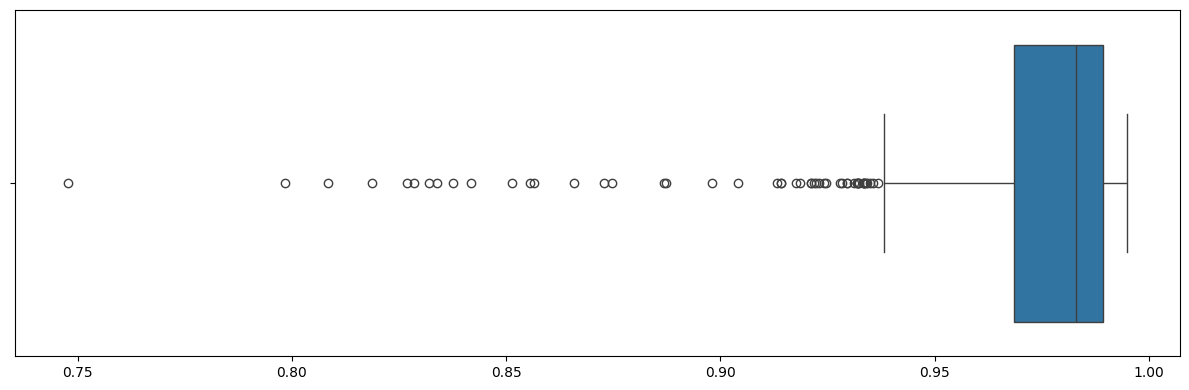

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

num_vals = [float(x) for x in similarities.values()]

plt.figure(figsize=(12,4))
sns.boxplot(x = num_vals)
plt.tight_layout()

In [8]:
from scipy.stats import beta

# Extract just the similarity scores into a numpy array
sim_data = np.array(list(similarities.values()))

# Fit the Beta distribution to our data
# We force loc=0 and scale=1 because our absolute cosine similarities are strictly bounded between 0 and 1
a, b, loc, scale = beta.fit(sim_data, floc=0, fscale=1)

# Find the threshold where only 5% of the distribution falls to the left
# PPF gives us the value at a specific percentile
threshold = beta.ppf(0.05, a, b)

print(f"Fitted Beta parameters: alpha={a:.2f}, beta={b:.2f}")
print(f"Regime Change Threshold (Bottom 5%): {threshold:.4f}")

# Identify the specific eras that are statistically anomalous
anomalous_eras = [era for era, score in similarities.items() if score < threshold]
print(f"Identified {len(anomalous_eras)} anomalous eras.")

Fitted Beta parameters: alpha=51.51, beta=1.46
Regime Change Threshold (Bottom 5%): 0.9285
Identified 34 anomalous eras.


In [9]:
# 1. Isolate the data for the 34 anomalous eras
anomalous_data = training_data[training_data['era'].isin(anomalous_eras)][feature_cols]

# 2. Fit the "Crisis PCA" ONLY on the anomalous data
crisis_pca = PCA(n_components=5) # Extracting the top 5 crisis factors
crisis_pca.fit(anomalous_data)

# 3. Apply (transform) the entire dataset using these crisis components
# We use .transform(), NOT .fit_transform() here!
crisis_features = crisis_pca.transform(training_data[feature_cols])

# 4. Add these new features back to your main DataFrame
for i in range(5):
    training_data[f'crisis_pca_{i}'] = crisis_features[:, i]

In [ ]:
np.sort(training_data['era'].unique(),)[-3:]

In [ ]:
# Assuming your 'era' column is currently a string like "0001", "0002"
# It is highly recommended to convert it to integers for mathematical filtering!
training_data['era_int'] = training_data['era'].astype(int)

train_start = 1
train_end_initial = 400
purge_size = 4
val_size = 30
num_folds = 5

for i in range(num_folds):
    # 1. The training window expands by 'val_size' each fold
    current_train_end = train_end_initial + (i * val_size)
    
    # 2. Purge gap immediately follows training
    purge_start = current_train_end + 1
    purge_end = current_train_end + purge_size
    
    # 3. Validation immediately follows the purge gap
    val_start = purge_end + 1
    val_end = purge_end + val_size
    
    print(f"Fold {i+1} | Train: [{train_start}-{current_train_end}] | Purge: [{purge_start}-{purge_end}] | Val: [{val_start}-{val_end}]")
    
    # 4. Filter the dataframe using our integer era column
    training_fold = training_data[
        (training_data['era_int'] >= train_start) & 
        (training_data['era_int'] <= current_train_end)
    ]
    
    val_fold = training_data[
        (training_data['era_int'] >= val_start) & 
        (training_data['era_int'] <= val_end)
    ]
    
    # ---> Here is where we will train the GBT and calculate the Spearman score!

In [10]:
import numpy as np
import lightgbm as lgb
from scipy.stats import spearmanr
import optuna

# Define the features we are training on (42 small features + 5 crisis components)
all_training_features = small_features + [f'crisis_pca_{i}' for i in range(5)]


In [ ]:
def objective(trial):
    # 1. The Menu: Optuna suggests hyperparameters for this specific trial
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': 200, # Keeping this moderate to save compute time at home
        'random_state': 42
    }
    
    fold_scores = []
    
    # Variables from our expanding window math
    train_start = 1
    train_end_initial = 400
    purge_size = 4
    val_size = 30
    num_folds = int((training_data['era_int'].max() - train_end_initial)/(val_size))
    
    # 2. The Time Machine: 5-Fold Expanding Window
    for i in range(num_folds):
        current_train_end = train_end_initial + (i * val_size)
        purge_end = current_train_end + purge_size
        val_start = purge_end + 1
        val_end = purge_end + val_size
        
        # Filter folds
        train_fold = training_data[(training_data['era_int'] >= train_start) & (training_data['era_int'] <= current_train_end)]
        val_fold = training_data[(training_data['era_int'] >= val_start) & (training_data['era_int'] <= val_end)]
        
        X_train, y_train = train_fold[all_training_features], train_fold['target']
        X_val, y_val = val_fold[all_training_features], val_fold['target']
        
        # 3. Train the Model
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        
        # 4. Predict on the unseen Validation block
        val_preds = model.predict(X_val)
        
        # 5. Evaluate: Calculate Spearman Rank Correlation
        # spearmanr returns the correlation and the p-value, we only need the correlation [0]
        score = spearmanr(val_preds, y_val)[0] 
        fold_scores.append(score)

    # Save the raw fold scores to the trial so we can analyze them later
    trial.set_user_attr("fold_scores", fold_scores)

    # 6. The Verdict: Calculate Sharpe Ratio
    # Add a tiny number to standard deviation to prevent dividing by zero!
    sharpe = np.mean(fold_scores) / (np.std(fold_scores) + 1e-9)
    
    return sharpe

In [ ]:
# Create a study and tell it we want to MAXIMIZE the Sharpe ratio
study = optuna.create_study(direction='maximize')

# Run 50 trials (guesses)
study.optimize(objective, n_trials=25)

print(f"Best hyperparameters found: {study.best_params}")

In [ ]:
import pandas as pd
import ast

# Dump the entire study history into a DataFrame
results_df = study.trials_dataframe()

# Sort by the best objective value (our Sharpe Ratio) descending
top_trials = results_df.sort_values(by='value', ascending=False).head(10)

# The fold scores are saved as strings in a column called 'user_attrs_fold_scores'
# Let's clean that up and print the top 5 trials
print("Top 5 Trials Analysis:")
print("-" * 50)

for index, row in top_trials.head(5).iterrows():
    trial_num = row['number']
    sharpe = row['value']
    
    # Extract the list of 5 scores
    scores = row['user_attrs_fold_scores']
    
    # Calculate stats
    mean_score = np.mean(scores)
    std_dev = np.std(scores)
    min_score = np.min(scores)
    
    print(f"Trial {trial_num} | Sharpe: {sharpe:.3f} | Mean: {mean_score:.4f} | Std: {std_dev:.4f}")
    print(f"Fold Scores: {[round(s, 4) for s in scores]}")
    print(f"Worst Fold: {min_score:.4f}\n")

In [ ]:
results_df[results_df['number'] == 12]

In [ ]:
import optuna.importance

# Calculate the importance of each parameter
importances = optuna.importance.get_param_importances(study)

print("Hyperparameter Importance:")
print("-" * 30)
for param, importance in importances.items():
    print(f"{param}: {importance * 100:.1f}%")

In [ ]:
import optuna.visualization as vis

# 1. Plot the parameter importance as a bar chart
fig1 = vis.plot_param_importances(study)
fig1.show()

# 2. Plot the relationship between a specific parameter and your score
# This shows you the "sweet spot" (e.g., does a max_depth of 4 always beat 8?)
fig2 = vis.plot_slice(study, params=['max_depth', 'learning_rate'])
fig2.show()

In [11]:

# Extract exactly what Trial 12 used from your Optuna study dataframe
# (Replace these with the exact values you found in Trial 12)
trial_12_params = {
    'max_depth': 4, 
    'learning_rate': 0.054,
    'n_estimators': 200,
    'random_state': 42
}

print("Training final model on ALL historical data...")
final_model = lgb.LGBMRegressor(**trial_12_params)

# Train on the entirety of `training_data`
X_train = training_data[all_training_features]
y_train = training_data['target']
final_model.fit(X_train, y_train)

Training final model on ALL historical data...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.149641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1485
[LightGBM] [Info] Number of data points in the train set: 2746268, number of used features: 47
[LightGBM] [Info] Start training from score 0.499948
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.054
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
import joblib

# Save the model using joblib
joblib.dump(final_model, 'lgbm_sklearn_model.pkl')

['lgbm_sklearn_model.pkl']

In [ ]:
from scipy.stats import spearmanr
print("Loading validation data...")

# Load the validation data using the exact same columns we used for training
validation_data = pd.read_parquet(f"validation.parquet", columns=columns_to_read)

# Apply the pre-fitted PCA to the validation data
# We assume 'crisis_pca' and 'small_features' are still in memory from earlier
print("Applying Crisis PCA factors to validation data...")
val_crisis_features = crisis_pca.transform(validation_data[small_features])

for i in range(5):
    validation_data[f'crisis_pca_{i}'] = val_crisis_features[:, i]

print("Scoring validation data era-by-era...")

# 1. THE FIX: Drop any rows where the target hasn't resolved yet
val_scored_df = validation_data.dropna(subset=['target']).copy()

# Generate predictions just for the resolved data
X_val = val_scored_df[all_training_features]
val_scored_df['predictions'] = final_model.predict(X_val)

validation_scores = []
unique_val_eras = val_scored_df['era'].unique()

for era in unique_val_eras:
    era_df = val_scored_df[val_scored_df['era'] == era]
    
    # 2. EXTRA SAFETY: Check if the model predicted the exact same constant 
    # value for every row (zero variance), which also causes Spearman to fail.
    if era_df['predictions'].nunique() <= 1:
        print(f"Warning: Model output constant predictions for era {era}. Skipping.")
        continue
        
    score = spearmanr(era_df['predictions'], era_df['target'])[0]
    
    # 3. Final check to ensure we only append valid numbers
    if not np.isnan(score):
        validation_scores.append(score)

# Calculate the final out-of-sample metrics
val_mean = np.mean(validation_scores)
val_std = np.std(validation_scores)
val_sharpe = val_mean / (val_std + 1e-9)

print("\n=== FINAL VALIDATION RESULTS ===")
print(f"Number of valid eras scored: {len(validation_scores)}")
print(f"Mean Correlation: {val_mean:.4f}")
print(f"Standard Deviation: {val_std:.4f}")
print(f"Validation Sharpe Ratio: {val_sharpe:.3f}")
print("================================")

In [19]:
# 1. Initialize API and find the current round
# (Assuming napi = numerapi.NumerAPI("YOUR_PUBLIC_KEY", "YOUR_SECRET_KEY") is already set)
current_round = napi.get_current_round()
print(f"Downloading live data for Round {current_round}...")

# 2. Download the live dataset
# The live data is much smaller than training data, so it downloads quickly
napi.download_dataset("v5.2/live.parquet", "live.parquet")


2026-03-28 03:07:07,091 INFO numerapi.utils: target file already exists
2026-03-28 03:07:07,093 INFO numerapi.utils: starting download
live.parquet: 20.1MB [00:07, 2.70MB/s]                                                                                                         


'live.parquet'

In [20]:

# 3. Load the live data
# CRITICAL: We MUST include the 'id' column this time!
live_columns = small_features
live_data = pd.read_parquet("live.parquet", columns=live_columns).reset_index()

print(f"Loaded {len(live_data)} live assets to predict.")

# 4. Apply the exact same Feature Engineering (Crisis PCA)
print("Applying Crisis PCA to live features...")
live_crisis_features = crisis_pca.transform(live_data[small_features])

for i in range(5):
    live_data[f'crisis_pca_{i}'] = live_crisis_features[:, i]

# 5. Generate Predictions using your locked-in final model
print("Generating predictions...")
X_live = live_data[all_training_features]
live_data['prediction'] = final_model.predict(X_live)

# 6. Format the submission file
# Numerai expects a CSV with exactly two columns: 'id' and 'prediction'
submission_df = live_data[['id','prediction']].copy()

# Ensure predictions are strictly between 0 and 1 (a requirement for Numerai)
# Tree models usually output values within the target range, but it's a good safety clip
submission_df['prediction'] = submission_df['prediction'].clip(0.0001, 0.9999)

Loaded 7211 live assets to predict.
Applying Crisis PCA to live features...
Generating predictions...


In [21]:
submission_filename = f"submission_round_{current_round}.csv"
submission_df.to_csv(submission_filename, index=False)
print(f"Saved predictions to {submission_filename}")

Saved predictions to submission_round_1233.csv


In [22]:
# 1. Get a dictionary of all your models { 'name': 'id' }
my_models = napi.get_models()

# 2. Set your model name exactly as it appears on the website
MY_MODEL_NAME = "your_model_name_here" 

# 3. Extract the ID for that specific name
if MY_MODEL_NAME in my_models:
    model_id = my_models[MY_MODEL_NAME]
    print(f"Found Model ID for {MY_MODEL_NAME}: {model_id}")
else:
    print(f"Error: Model name '{MY_MODEL_NAME}' not found in your account!")
    print(f"Available models are: {list(my_models.keys())}")

Error: Model name 'your_model_name_here' not found in your account!
Available models are: ['solidburak', 'first_model41']


In [23]:
# 7. Upload to the Tournament!
print("Uploading to Numerai...")
model_id = napi.get_models()['first_model41'] # Replace with your exact model name from the website
napi.upload_predictions(submission_filename, model_id=model_id)

print("Submission complete! 🎉")

Uploading to Numerai...


2026-03-28 03:07:59,757 INFO numerapi.base_api: uploading predictions...


Submission complete! 🎉


In [ ]:
sns.histplot(validation_scores)